# 第 0 课：环境与第一次前向

不训练模型。先验证 kernel、路径、数据与张量接口。

In [1]:
from pathlib import Path
import sys
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/hsi_learning').is_dir() and (p / 'dataset').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from inside the HSI-Learning repository')
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np
import torch
# Notebook kernels must explicitly use inline rendering even when the CLI
# parent uses MPLBACKEND=Agg for non-interactive training scripts.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
import matplotlib.pyplot as plt
from hsi_learning.data import load_hsi_dataset
from hsi_learning.teaching_runs import load_bundle, encode_ids
from hsi_learning.teaching import patches_at, prototype_logits, prototypes, grad_cam
from hsi_learning.teaching_plots import style, maps
style()
torch.set_num_threads(2)
print('Python:', sys.executable)
print('Repository:', ROOT)


Python: D:\JupyterWorkSpace\HSI-Learning\.venv\Scripts\python.exe
Repository: D:\JupyterWorkSpace\HSI-Learning


{'python': '3.13.13', 'numpy': '2.5.0', 'torch': '2.14.0+cpu', 'scipy': '1.18.0', 'sklearn': '1.9.1'}
cube: (145, 145, 200) float32 GT: (145, 145) labeled: 10249


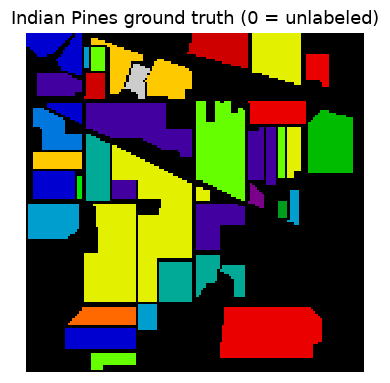

In [2]:
import platform, scipy, sklearn
print({'python': platform.python_version(), 'numpy': np.__version__,
       'torch': torch.__version__, 'scipy': scipy.__version__, 'sklearn': sklearn.__version__})
cube, gt, names = load_hsi_dataset('IP', ROOT/'dataset')
assert cube.shape[:2] == gt.shape
assert set(np.unique(gt)) <= set(range(len(names)+1))
print('cube:', cube.shape, cube.dtype, 'GT:', gt.shape, 'labeled:', np.count_nonzero(gt))
plt.imshow(gt, cmap='nipy_spectral', vmin=0, vmax=len(names), interpolation='nearest')
plt.title('Indian Pines ground truth (0 = unlabeled)'); plt.axis('off'); plt.show()


In [3]:
from hsi_learning.teaching import PatchClassifier
model = PatchClassifier(12, len(names)).eval()
with torch.no_grad(): logits = model(torch.zeros(2,12,9,9))
BATCH_SIZE = 2  # exercise: change this and the input together
with torch.no_grad(): logits = model(torch.zeros(BATCH_SIZE,12,9,9))
assert logits.shape == (BATCH_SIZE,len(names))
print('Input (2,12,9,9) -> logits', tuple(logits.shape))
print('Random weights: this is an interface check, NOT a classification result.')


Input (2,12,9,9) -> logits (2, 16)
Random weights: this is an interface check, NOT a classification result.


## 练习
把 batch 改成3、类别数改成9；预测输出形状并验证。排错先检查 sys.executable，不要盲目重装包。